# 0) Imports

In [1]:
# install the main library YFinance
!pip install yfinance

In [2]:
# IMPORTS
import numpy as np
import pandas as pd

#Fin Data Sources
import yfinance as yf
import pandas_datareader as pdr

#Data viz
import plotly.graph_objs as go
import plotly.express as px

import time
from datetime import date


# 1) Understanding Data-Driven Decisions data pulls

In [3]:
end = date.today()
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

start = date(year=end.year-70, month=end.month, day=end.day)
print(f'Period for indexes: {start} to {end} ')

Year = 2026; month= 9; day=13
Period for indexes: 1956-09-13 to 2026-09-13 


## 1.1) GDP

In [4]:
# Real Potential Gross Domestic Product (GDPPOT), Billions of Chained 2012 Dollars, QUARTERLY
# https://fred.stlouisfed.org/series/GDPPOT
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)

In [5]:
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
gdppot.tail(15)

,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


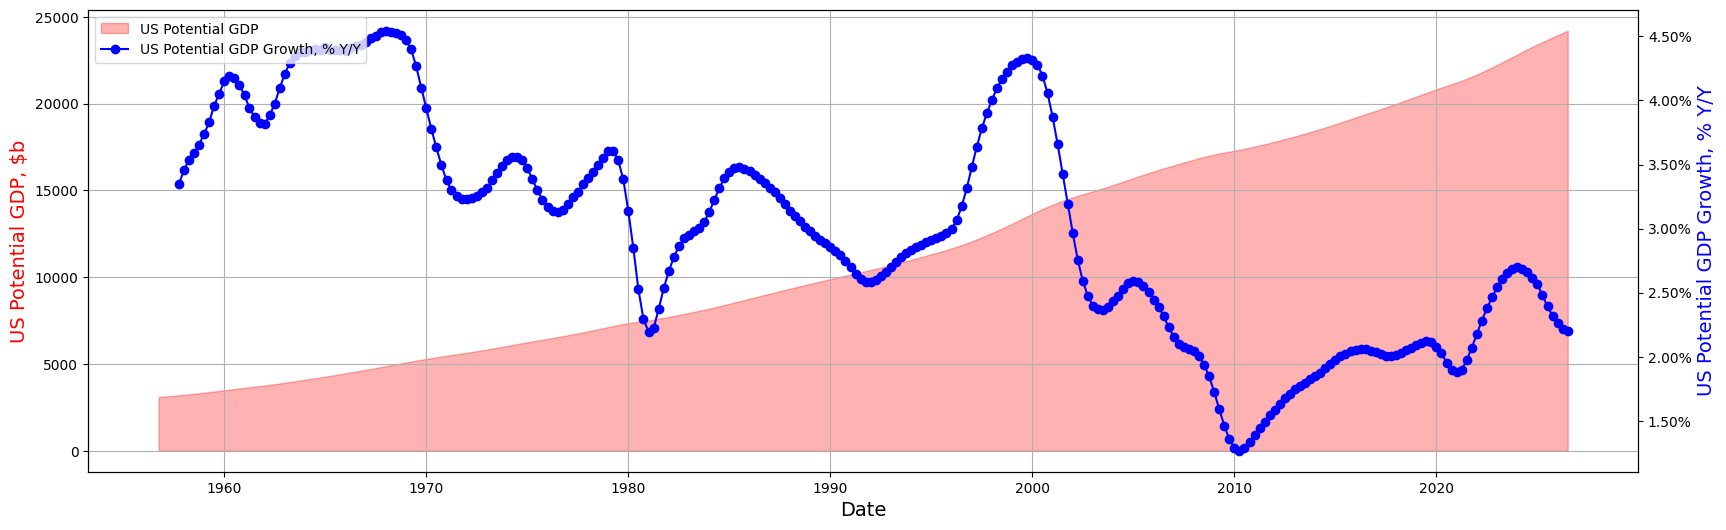

In [6]:
# Visuals GDPPOT
# https://cmdlinetips.com/2019/10/how-to-make-a-plot-with-two-different-y-axis-in-python-with-matplotlib/

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# Creating a secondary y-axis for GDP growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.2) Inflation - CPI Core

In [7]:
# # "Core CPI index", MONTHLY
# https://fred.stlouisfed.org/series/CPILFESL
# The "Consumer Price Index for All Urban Consumers: All Items Less Food & Energy"
# is an aggregate of prices paid by urban consumers for a typical basket of goods, excluding food and energy.
# This measurement, known as "Core CPI," is widely used by economists because food and energy have very volatile prices.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)

In [8]:
cpilfesl.head()

,CPILFESL
DATE,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


In [9]:
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

cpilfesl.tail(13)

,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958
2026-04-01,335.423,0.027433,0.003765


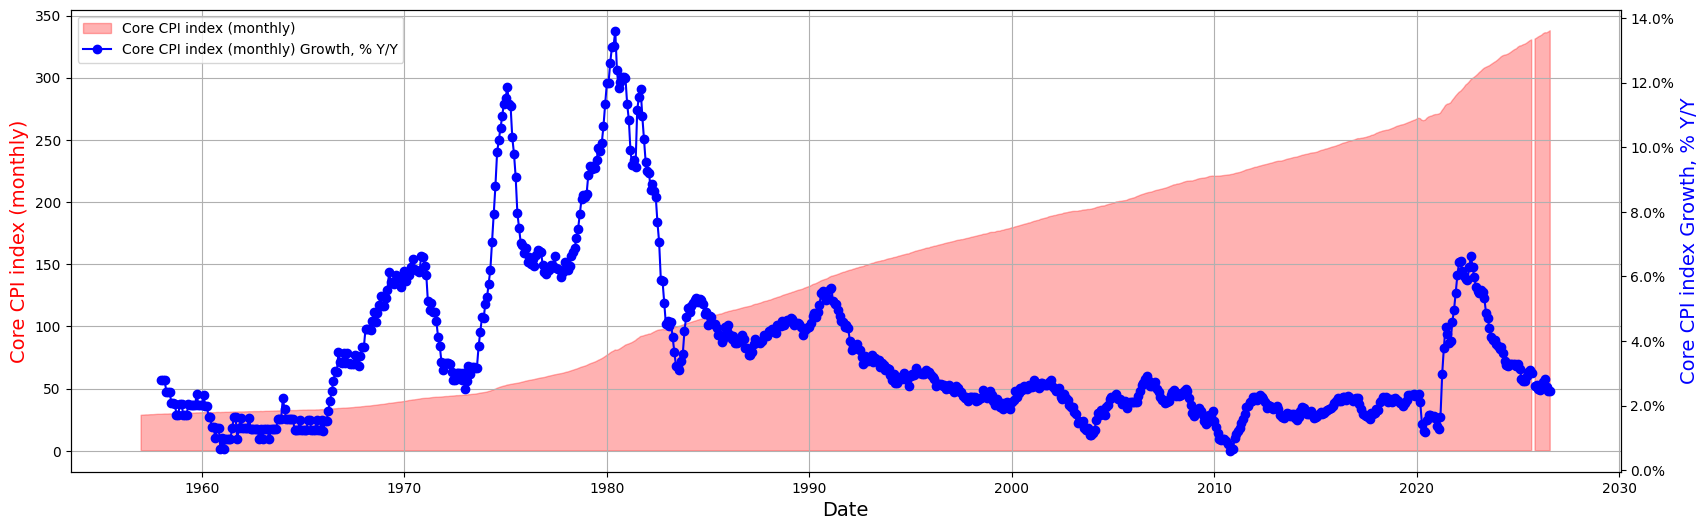

In [10]:
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under CPI
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# Creating a secondary y-axis for CPI growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

## 1.3 Interest rates

In [11]:
# Fed rate https://fred.stlouisfed.org/series/FEDFUNDS
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
fedfunds.tail(10)

,FEDFUNDS
DATE,
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63
2026-07-01,3.63


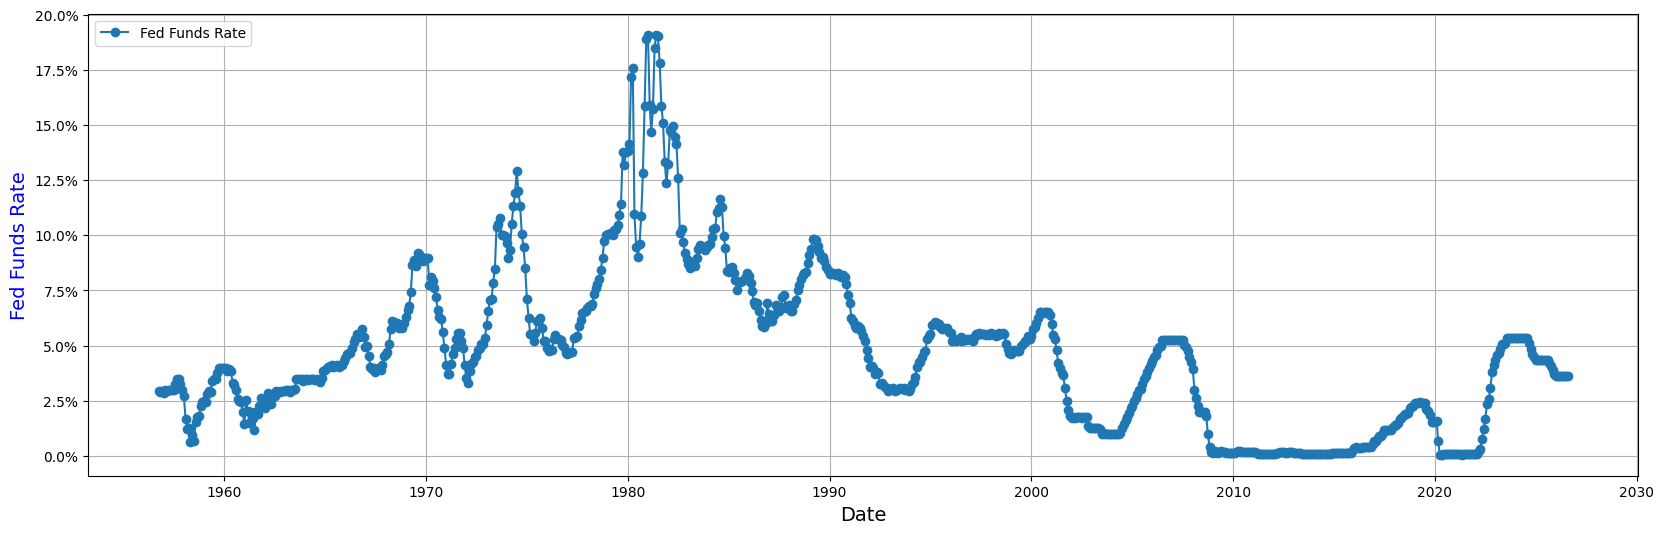

In [12]:
# Fed Funds
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under US potential GDP curve
# ax.fill_between(fedfunds.index, fedfunds.FEDFUNDS, color="red", alpha=0.3, label="Core CPI index (monthly)")

# # Creating a secondary y-axis for GDP growth percentage
# ax2 = ax.twinx()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

plt.show()

In [13]:
# https://fred.stlouisfed.org/series/DGS1
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
dgs1.tail()

,DGS1
DATE,
2026-09-04,4.13
2026-09-07,NaN
2026-09-08,4.15
2026-09-09,4.17
2026-09-10,4.28


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [14]:
# https://fred.stlouisfed.org/series/DGS5
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
dgs5.tail()

,DGS5
DATE,
2026-09-04,4.54
2026-09-07,NaN
2026-09-08,4.57
2026-09-09,4.61
2026-09-10,4.75


## 1.4 SNP500

In [15]:
import yfinance as yf

# Other indexes: https://stooq.com/t/ ; https://stooq.com/t/?i=510  --main indexes
# USED TO BE ABLE TO GET DATA FROM STOOQ USING PDR - NOW, WE USE YAHOO FINANCE
# https://pandas-datareader.readthedocs.io/en/latest/remote_data.html


# SPX= S&P500
ticker_obj = yf.Ticker("^SPX")
spx_index = ticker_obj.history(start=start, end=end)
spx_index.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,4966930000,0.0,0.0
2026-09-09 00:00:00-04:00,7660.680176,7660.680176,7624.160156,7636.359863,4896940000,0.0,0.0
2026-09-10 00:00:00-04:00,7594.740234,7612.859863,7580.060059,7591.700195,4893500000,0.0,0.0
2026-09-11 00:00:00-04:00,7636.750000,7677.020020,7636.750000,7656.979980,4722480000,0.0,0.0


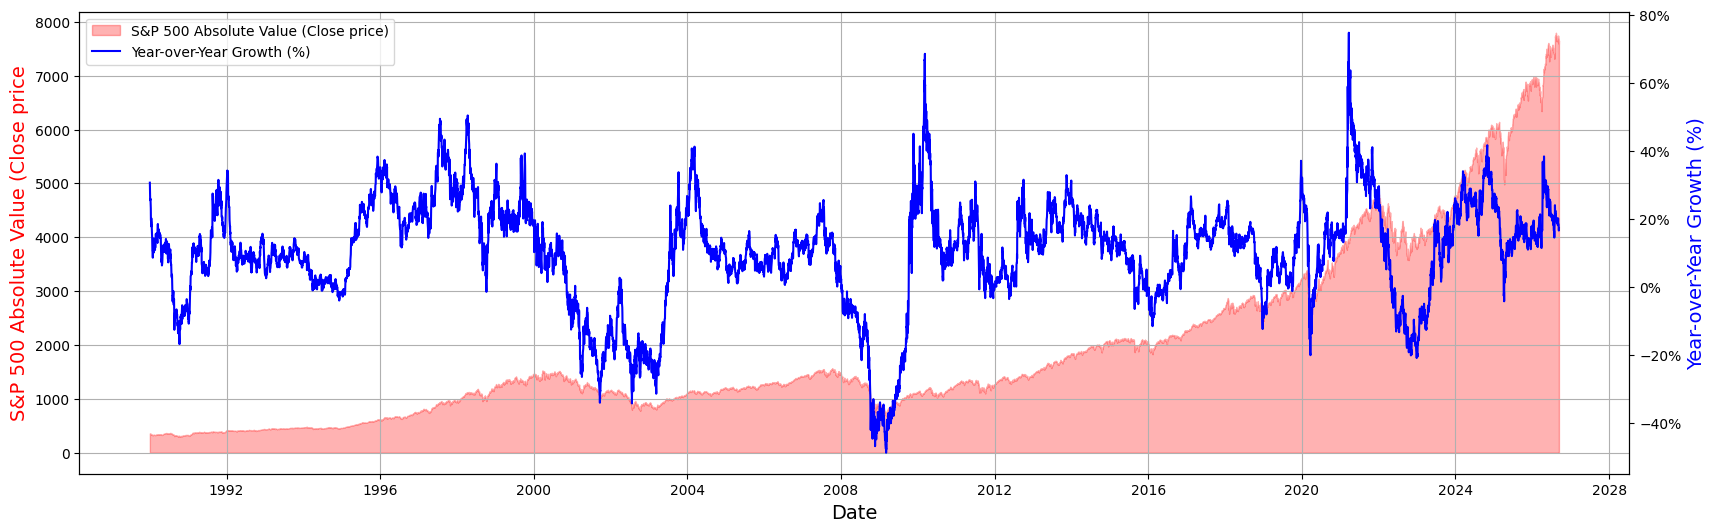

In [16]:
spx_index['spx_yoy'] = (spx_index.Close / spx_index.Close.shift(252)) - 1

# Re-truncate the DataFrame after recalculating 'spx_yoy' to ensure data consistency
spx_truncated = spx_index[spx_index.index>='1990-01-01']

# S&P500 abs. vs. relative growth
fig, ax = plt.subplots(figsize=(20, 6))
plt.grid(True)

# Plotting area under S&P 500 Close price
ax.fill_between(spx_truncated.index, spx_truncated.Close, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# Creating a secondary y-axis for S&P 500 year-over-year growth percentage
ax2 = ax.twinx()
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.plot(spx_truncated.spx_yoy,
         color="blue",
        #  marker=".",
         label="Year-over-Year Growth (%)")

# Setting labels and title
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("S&P 500 Absolute Value (Close price", color="red", fontsize=14)
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# Adding legend
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [20]:
# INDEXES from Yahoo Finance
# DAX index (XETRA - XETRA Delayed Price. Currency in EUR)
# WEB: https://finance.yahoo.com/quote/%5EGDAXI
# Option 1: dax_daily = yf.download(tickers = ["^GDAXI"],
#                      period = "max",
#                      interval = "1d")

# Option 2 (preferred):
# Download data with Adj Close for more accurate price reflections
ticker_obj = yf.Ticker("^GDAXI")
dax_daily = ticker_obj.history(start = start)

In [21]:
dax_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-07 00:00:00+02:00,26039.539062,26069.990234,25919.609375,26006.529297,35638000,0.0,0.0
2026-09-08 00:00:00+02:00,25897.220703,26026.779297,25799.660156,26007.630859,42236700,0.0,0.0
2026-09-09 00:00:00+02:00,25870.980469,25909.660156,25512.390625,25576.449219,53670200,0.0,0.0
2026-09-10 00:00:00+02:00,25555.660156,25612.089844,25361.150391,25361.150391,49936000,0.0,0.0
2026-09-11 00:00:00+02:00,25478.839844,25581.220703,25396.380859,25568.560547,45275400,0.0,0.0


In [22]:
# normally 252 trading days
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1

In [23]:
dax_daily

,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-09-07 00:00:00+02:00,26039.539062,26069.990234,25919.609375,26006.529297,35638000,0.0,0.0,23807.130859,0.092384
2026-09-08 00:00:00+02:00,25897.220703,26026.779297,25799.660156,26007.630859,42236700,0.0,0.0,23718.449219,0.096515
2026-09-09 00:00:00+02:00,25870.980469,25909.660156,25512.390625,25576.449219,53670200,0.0,0.0,23632.949219,0.082237


<Axes: xlabel='Date'>

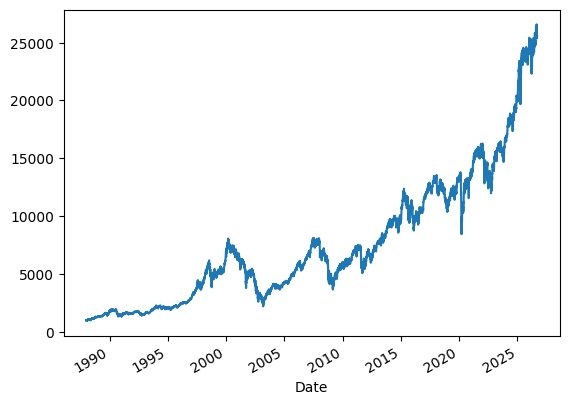

In [24]:
dax_daily['Close'].plot.line()

In [25]:
# delayed 15 min : https://finance.yahoo.com/quote/%5ESPX/
# S&P 500 INDEX : Chicago Options - Chicago Options Delayed Price. Currency in USD
ticker_obj = yf.Ticker("^SPX")
snp500_daily = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily = yf.download(tickers = "^SPX",
#                      period = "max",
#                      interval = "1d")

In [26]:
snp500_daily.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,4966930000,0.0,0.0
2026-09-09 00:00:00-04:00,7660.680176,7660.680176,7624.160156,7636.359863,4896940000,0.0,0.0
2026-09-10 00:00:00-04:00,7594.740234,7612.859863,7580.060059,7591.700195,4893500000,0.0,0.0
2026-09-11 00:00:00-04:00,7636.750000,7677.020020,7636.750000,7656.979980,4722480000,0.0,0.0


In [27]:
# https://finance.yahoo.com/quote/%5EGSPC/
# SNP - SNP Real Time Price. Currency in USD
# https://www.investopedia.com/insights/introduction-to-stock-market-indices/

ticker_obj = yf.Ticker("^GSPC")
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")

# old version:
# snp500_daily_non_delayed = yf.download(tickers = "^GSPC",
#                      period = "max",
#                      interval = "1d")

In [28]:
snp500_daily_non_delayed.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-09-04 00:00:00-04:00,7750.189941,7750.189941,7706.120117,7718.600098,4103570000,0.0,0.0
2026-09-08 00:00:00-04:00,7717.810059,7717.810059,7666.990234,7673.520020,4966930000,0.0,0.0
2026-09-09 00:00:00-04:00,7660.680176,7660.680176,7624.160156,7636.359863,4896940000,0.0,0.0
2026-09-10 00:00:00-04:00,7594.740234,7612.859863,7580.060059,7591.700195,4893500000,0.0,0.0
2026-09-11 00:00:00-04:00,7636.750000,7677.020020,7636.750000,7656.979980,4722480000,0.0,0.0


In [29]:
# Dow Jones Industrial Average: https://finance.yahoo.com/quote/%5EDJI?.tsrc=fin-srch

ticker_obj = yf.Ticker("^DJI")
dji_daily = ticker_obj.history(start = start, interval = "1d")

# dji_daily = yf.download(tickers = "^DJI",
#                      period = "max",
#                      interval = "1d")

## 2.2 OHLCV data daily - ETFs

In [30]:
# https://finance.yahoo.com/quote/VOO?.tsrc=fin-srch

ticker_obj = yf.Ticker("VOO")
voo_etf = ticker_obj.history(start = start, interval = "1d")

# voo_etf = yf.download(tickers = "VOO",
#                      period = "max",
#                      interval = "1d")


In [31]:
voo_etf.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-09-04 00:00:00-04:00,709.719971,710.450012,706.900024,708.010010,6806600,0.0,0.0,0.0
2026-09-08 00:00:00-04:00,706.979980,707.510010,703.369995,704.070007,7827600,0.0,0.0,0.0
2026-09-09 00:00:00-04:00,702.349976,702.710022,699.489990,700.869995,4293300,0.0,0.0,0.0
2026-09-10 00:00:00-04:00,696.780029,698.640015,695.539978,696.650024,18313400,0.0,0.0,0.0
2026-09-11 00:00:00-04:00,703.000000,704.500000,701.929993,702.559998,5792000,0.0,0.0,0.0


In [32]:
# ETFs
# WisdomTree India Earnings Fund (EPI)
# NYSEArca - Nasdaq Real Time Price. Currency in USD
# WEB: https://finance.yahoo.com/quote/EPI/history?p=EPI

ticker_obj = yf.Ticker("EPI")
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")

# epi_etf_daily = yf.download(tickers = "EPI",
#                      period = "max",
#                      interval = "1d")

In [33]:
epi_etf_daily.head()
print(epi_etf_daily.shape)

(4666, 8)


In [34]:
# find dividends impact on Close vs. Adj.Close
epi_etf_daily[epi_etf_daily.Dividends>0].tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577710,33.801812,33.577710,33.764462,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420327,29.778748,29.370547,29.768791,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [35]:
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [36]:
# find dividends - diff for Close vs. Adj Close
# Open/Close for 06-25 diff is close to divs = 1.845 (~1.58 for Open and 1.3 for Close)
# HELP: https://help.yahoo.com/kb/SLN28256.html#:~:text=Adjusted%20close%20is%20the%20closing,Security%20Prices%20(CRSP)%20standards.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [37]:
# Previous option : no Div. dates , same stats
epi_etf_daily2 = yf.download(tickers = "EPI",
                     period = "max",
                     interval = "1d")

/tmp/ipykernel_480/3463259538.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  epi_etf_daily2 = yf.download(tickers = "EPI",
[*********************100%***********************]  1 of 1 completed


In [38]:
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()

Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

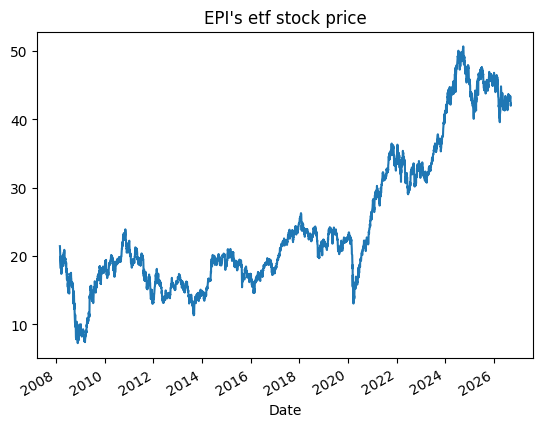

In [39]:
# About yFinance: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

epi_etf_daily['Close'].plot(title="EPI's etf stock price")

In [40]:
# get actions, incl. dividends - as a dataFrame
epi = yf.Ticker('EPI')
epi.get_actions()

,Dividends,Stock Splits,Capital Gains
Date,,,
2008-12-22 00:00:00-05:00,0.091,0.0,0.0
2009-03-23 00:00:00-04:00,0.007,0.0,0.0
2009-06-22 00:00:00-04:00,0.002,0.0,0.0
2009-09-21 00:00:00-04:00,0.045,0.0,0.0
2009-12-21 00:00:00-05:00,0.006,0.0,0.0
2010-06-28 00:00:00-04:00,0.065,0.0,0.0
2010-09-20 00:00:00-04:00,0.065,0.0,0.0
2010-12-22 00:00:00-05:00,0.013,0.0,0.0
2011-06-22 00:00:00-04:00,0.062,0.0,0.0


In [41]:
# get dividends as Series
epi.get_dividends()

,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006
2010-06-28 00:00:00-04:00,0.065
2010-09-20 00:00:00-04:00,0.065
2010-12-22 00:00:00-05:00,0.013
2011-06-22 00:00:00-04:00,0.062


In [42]:
# India's stock example
# https://www.nseindia.com/market-data/live-equity-market
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     period = "max",
                     interval = "1d")

/tmp/ipykernel_480/1576332518.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
[*********************100%***********************]  1 of 1 completed


In [43]:
EICHERMOT

Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.119487,1.119487,1.119487,1.119487,22000
1996-01-02,1.122597,1.131926,1.119487,1.119487,31000
1996-01-03,1.135035,1.135035,1.135035,1.135035,11000
1996-01-04,1.135035,1.135035,1.119487,1.119487,16000
1996-01-05,1.119487,1.135035,1.100829,1.135035,6000
...,...,...,...,...,...
2026-09-04,7630.500000,7665.500000,7590.000000,7665.000000,492954
2026-09-08,7747.500000,7747.500000,7655.000000,7700.000000,461637


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [ ]:
# [Polygon.io] Please read the article (section "Polygon.io News API"): https://pythoninvest.com/long-read/chatgpt-api-for-financial-news-summarization
# Endpoint: https://polygon.io/docs/stocks/get_v2_reference_news

In [ ]:
# [Alpha Vantage] Please read the article (section "Data Sources"): https://pythoninvest.com/long-read/stock-screening-using-paid-data
# Endpoint: https://www.alphavantage.co/documentation/#fundamentals

## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [ ]:
# Gold reserves excl. gold for China
# https://fred.stlouisfed.org/series/TRESEGCNM052N

In [44]:
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)

<Axes: xlabel='DATE'>

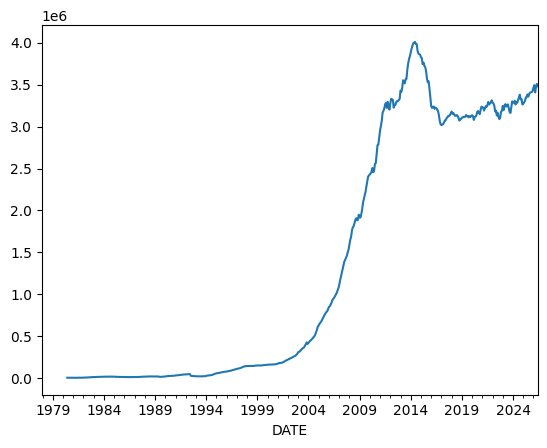

In [45]:
gold_reserves.TRESEGCNM052N.plot.line()

In [46]:
#  CBOE Gold ETF Volatility Index (GVZCLS)
# https://fred.stlouisfed.org/series/GVZCLS
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)

<Axes: xlabel='DATE'>

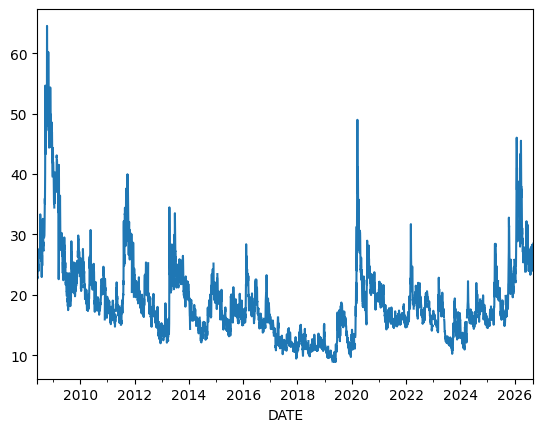

In [47]:
gold_volatility.GVZCLS.plot.line()

In [48]:
#  Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma (DCOILWTICO)
# https://fred.stlouisfed.org/series/DCOILWTICO
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)

<Axes: xlabel='DATE'>

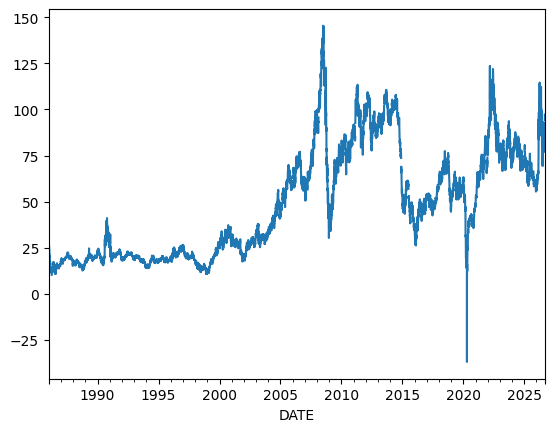

In [49]:
# there is a bug in the data? negative price?
oil_wti.DCOILWTICO.plot.line()

In [50]:
# Crude Oil Prices: Brent - Europe (DCOILBRENTEU)
# https://fred.stlouisfed.org/series/DCOILBRENTEU
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)

<Axes: xlabel='DATE'>

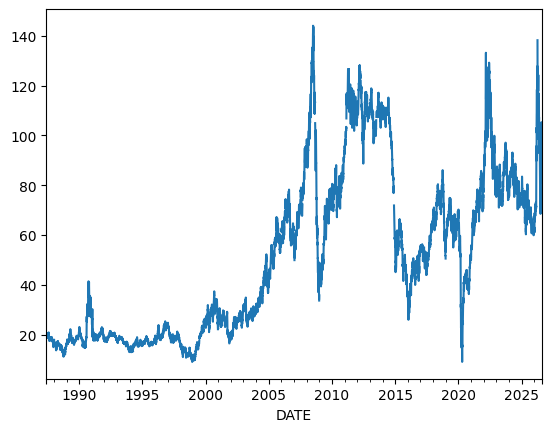

In [ ]:
oil_brent.DCOILBRENTEU.plot.line()

In [51]:
# Web Scraping for Macro
# can't call directly via pd.read_html() as it returns 403 (forbidden) --> need to do a bit of work, but still no Selenium
# https://tradingeconomics.com/united-states/indicators
import requests
from bs4 import BeautifulSoup


url = "https://tradingeconomics.com/united-states/indicators"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

response = requests.get(url, headers=headers)

In [52]:

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # You need to be able to find this table tag and read all behind it
    # Find the div with class "table-responsive"
    table_div = soup.find("div", class_="table-responsive")

    # Extract the table within the div
    table = table_div.find("table")

    # Use pandas to read the table into a DataFrame
    df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list

    # Display the DataFrame
    print(df)
else:
    print("Failed to retrieve data from the webpage.")

                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    99.09     99.05   165.00     70.70   
1               Stock Market  7657.00   7592.00  7817.00      4.40   
2            GDP Growth Rate     1.50      2.10    34.90    -28.00   
3     GDP Annual Growth Rate     2.10      2.70    13.40     -7.40   
4          Unemployment Rate     4.10      4.10    14.80      2.50   
5          Non Farm Payrolls   162.00     21.00  4631.00 -20469.00   
6             Inflation Rate     3.40      3.40    23.70    -15.80   
7         Inflation Rate MoM     0.40      0.10     2.00     -1.80   
8              Interest Rate     3.75      3.75    20.00      0.25   
9           Balance of Trade   -88.58    -71.18     1.95   -133.00   
10           Current Account  -227.00   -221.00     9.96   -438.00   
11    Current Account to GDP    -3.60     -4.00     0.20     -6.00   
12    Government Debt to GDP   123.00    122.00   126.00     31.80   
13         Governmen

/tmp/ipykernel_480/51921383.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]  # Assuming there's only one table, otherwise, loop through the list


In [53]:
df

,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,99.09,99.05,165.00,70.70,NaN,Sep/26
1,Stock Market,7657.00,7592.00,7817.00,4.40,points,Sep/26
2,GDP Growth Rate,1.50,2.10,34.90,-28.00,percent,Jun/26
3,GDP Annual Growth Rate,2.10,2.70,13.40,-7.40,percent,Jun/26
4,Unemployment Rate,4.10,4.10,14.80,2.50,percent,Aug/26
5,Non Farm Payrolls,162.00,21.00,4631.00,-20469.00,Thousand,Aug/26
6,Inflation Rate,3.40,3.40,23.70,-15.80,percent,Aug/26
7,Inflation Rate MoM,0.40,0.10,2.00,-1.80,percent,Aug/26
8,Interest Rate,3.75,3.75,20.00,0.25,percent,Aug/26
9,Balance of Trade,-88.58,-71.18,1.95,-133.00,USD Billion,Jul/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [54]:
# let's check for NVDA
nvda =  yf.Ticker('NVDA')

In [55]:
# yearly financials for the last 4 years
nvda.financials


,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,-2.841300e+08,NaN
Tax Rate For Calcs,1.511700e-01,1.326490e-01,1.200000e-01,2.100000e-01,NaN
Normalized EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,7.339000e+09,NaN
Total Unusual Items,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Total Unusual Items Excluding Goodwill,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Net Income From Continuing Operation Net Minority Interest,1.200670e+11,7.288000e+10,2.976000e+10,4.368000e+09,NaN
Reconciled Depreciation,2.843000e+09,1.864000e+09,1.508000e+09,1.543000e+09,NaN
Reconciled Cost Of Revenue,6.247500e+10,3.263900e+10,1.662100e+10,1.161800e+10,NaN
EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,5.986000e+09,NaN
EBIT,1.417090e+11,8.427300e+10,3.407500e+10,4.443000e+09,NaN


In [56]:
# balance sheet
nvda.balance_sheet

,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Share Issued,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Net Debt,NaN,NaN,2.429000e+09,7.564000e+09,8.956000e+09
Total Debt,1.104000e+10,9.982000e+09,1.105600e+10,1.203100e+10,NaN
Tangible Book Value,1.331550e+11,7.333200e+10,3.743600e+10,1.605300e+10,NaN
...,...,...,...,...,...
Receivables,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Accounts Receivable,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Cash Cash Equivalents And Short Term Investments,6.255600e+10,4.321000e+10,2.598400e+10,1.329600e+10,NaN
Other Short Term Investments,5.195100e+10,3.462100e+10,1.870400e+10,9.907000e+09,NaN


In [57]:
# Basic info:
nvda.fast_info

lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [58]:
# marketCap is quite useful, but don't know when it was updated? Daily?
nvda.fast_info['marketCap']/1e9

5271.048467880249

In [ ]:
# read this article for full info: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html

## 2.6 Web Scraping - company info for clustering

In [59]:
# ask chatGPT: emulate clicking the link and downloading the content
import requests
from bs4 import BeautifulSoup

# URL of the webpage
url = "https://companiesmarketcap.com/"

# Define headers with a user-agent to mimic a web browser
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# Send a GET request to the URL with headers
response = requests.get(url, headers=headers)

# Check if the request was successful (status code 200)
if response.status_code == 200:
    # Parse the HTML content of the webpage
    soup = BeautifulSoup(response.content, "html.parser")

    # Find the download link within the webpage
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})

    # If the download link is found
    if download_link:
        # Extract the href attribute which contains the actual download link
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]

        # Download the CSV file using the obtained download URL
        download_response = requests.get(download_url, headers=headers)

        # Check if the download request was successful
        if download_response.status_code == 200:
            # Save the content of the response to a local file
            with open("global_stocks.csv", "wb") as f:
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        else:
            print("Failed to download the CSV file.")
    else:
        print("Download link not found on the webpage.")
else:
    print("Failed to retrieve data from the webpage.")

CSV file downloaded successfully.


In [60]:
global_stocks = pd.read_csv("/content/global_stocks.csv")

In [61]:
global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9

In [62]:
global_stocks.head(10)

,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,NVIDIA,NVDA,5271048421376,218.29000,United States,5271.048421
1,2,Apple,AAPL,4849207869440,332.27000,United States,4849.207869
2,3,Alphabet (Google),GOOG,4102531842048,335.45000,United States,4102.531842
3,4,Microsoft,MSFT,3680323239936,495.63000,United States,3680.323240
4,5,Amazon,AMZN,2769709432832,256.78000,United States,2769.709433
5,6,TSMC,TSM,2246988005376,433.24000,Taiwan,2246.988005
6,7,SpaceX,SPCX,1993217015808,151.21000,United States,1993.217016
7,8,Broadcom,AVGO,1728006324224,361.99000,United States,1728.006324
8,9,Saudi Aramco,2222.SR,1683786162198,6.96046,Saudi Arabia,1683.786162
9,10,Meta Platforms (Facebook),META,1650860490752,648.03000,United States,1650.860491


In [63]:
global_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11336 entries, 0 to 11335
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             11336 non-null  int64  
 1   Name             11336 non-null  object 
 2   Symbol           11335 non-null  object 
 3   marketcap        11336 non-null  int64  
 4   price (USD)      11336 non-null  float64
 5   country          11336 non-null  object 
 6   marketcap_b_usd  11336 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 620.1+ KB


#Home_Assignment_Module_01_Hyeri

##Question 1: [Index] S&P 500 Stocks Added to the Index

###1. Which year had the highest number of additions (starting from 2020)? (2 points)
####2025 / 2024 / 2023 / 2022

In [64]:
import pandas as pd
import requests

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

# Fetch the HTML content with headers
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

sp500 = tables[0]

sp500.head()

/tmp/ipykernel_480/3813447220.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [66]:
#Check the columns
sp500.columns

Index(['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry',
       'Headquarters Location', 'Date added', 'CIK', 'Founded'],
      dtype='object')

In [70]:
#Bring Symbol & Security & Date added
sp500_small = sp500[['Symbol', 'Security', 'Date added']].copy()

sp500_small.head()

,Symbol,Security,Date added
0,MMM,3M,1957-03-04
1,AOS,A. O. Smith,2017-07-26
2,ABT,Abbott Laboratories,1957-03-04
3,ABBV,AbbVie,2012-12-31
4,ACN,Accenture,2011-07-06


In [71]:
sp500_small['Date added'] = pd.to_datetime(
    sp500_small['Date added'],
    errors='coerce'
)

In [74]:
#Extract the year
sp500_small['Year_added'] = sp500_small['Date added'].dt.year

In [75]:
#After 2020
added_since_2020 = sp500_small[
    sp500_small['Year_added'] >= 2020
]

added_since_2020.head()

,Symbol,Security,Date added,Year_added
11,ABNB,Airbnb,2023-09-18,2023
37,APO,Apollo Global Management,2024-12-23,2024
40,APP,AppLovin,2025-09-22,2025
42,ACGL,Arch Capital Group,2022-11-01,2022
44,ARES,Ares Management,2025-12-11,2025


In [76]:
#Group by year
year_counts = (
    added_since_2020
    .groupby('Year_added')
    .size()
    .sort_values(ascending=False)
)

year_counts

,0
Year_added,
2025,18
2024,16
2022,15
2023,15
2026,13
2021,10
2020,10


In [79]:
#Answer
print("Year:", year_counts.idxmax())
print("Number of additions:", year_counts.max())

Year: 2025
Number of additions: 18


###1. Which year had the highest number of additions (starting from 2020)? (2 points)
####2025

###Additional: How many current S&P 500 stocks have been in the index for more than 20 years?

In [80]:
cutoff_date = pd.Timestamp.today() - pd.DateOffset(years=20)

more_than_20_years = sp500_small[
    sp500_small['Date added'] < cutoff_date
]

len(more_than_20_years)

224

###Additional: How many current S&P 500 stocks have been in the index for more than 20 years?
####224

###2. How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026? (3 points)
####1 / 2 / 3 / 4

In [81]:
#11 indexes
indexes = {
    'US': '^GSPC',
    'China': '000001.SS',
    'Hong Kong': '^HSI',
    'Australia': '^AXJO',
    'India': '^NSEI',
    'Canada': '^GSPTSE',
    'Germany': '^GDAXI',
    'UK': '^FTSE',
    'Japan': '^N225',
    'Mexico': '^MXX',
    'Brazil': '^BVSP'
}

In [82]:
#Bring data
import yfinance as yf
import pandas as pd

start_date = '2026-01-01'
end_date = '2026-08-21'

indexes = {
    'US': '^GSPC',
    'China': '000001.SS',
    'Hong Kong': '^HSI',
    'Australia': '^AXJO',
    'India': '^NSEI',
    'Canada': '^GSPTSE',
    'Germany': '^GDAXI',
    'UK': '^FTSE',
    'Japan': '^N225',
    'Mexico': '^MXX',
    'Brazil': '^BVSP'
}

data = yf.download(
    list(indexes.values()),
    start=start_date,
    end=end_date,
    auto_adjust=False
)

data.head()

[*********************100%***********************]  11 of 11 completed


Price         Adj Close                                                     \
Ticker        000001.SS        ^AXJO     ^BVSP         ^FTSE        ^GDAXI   
Date                                                                         
2026-01-01          NaN          NaN       NaN           NaN           NaN   
2026-01-02          NaN  8727.799805  160539.0   9951.099609  24539.339844   
2026-01-05  4023.416992  8728.599609  161870.0  10004.599609  24868.689453   
2026-01-06  4083.666992  8714.599609  163664.0  10122.700195  24892.199219   
2026-01-07  4085.771973  8695.599609  161975.0  10048.200195  25122.259766   

Price                                                              \
Ticker            ^GSPC       ^GSPTSE          ^HSI          ^MXX   
Date                                                                
2026-01-01          NaN           NaN           NaN           NaN   
2026-01-02  6858.470215  31883.400391  26338.470703  64141.359375   
2026-01-05  6902.049805  32220.000000  26347.240234  65014.371094   
2026-01-06  6944.819824  32407.000000  26710.449219  65022.238281   
2026-01-07  6920.930176  32135.500000  26458.949219  64871.699219   

Price                     ...    Volume                                      \
Ticker             ^N225  ...     ^AXJO      ^BVSP        ^FTSE      ^GDAXI   
Date                      ...                                                 
2026-01-01           NaN  ...       NaN        NaN          NaN         NaN   
2026-01-02           NaN  ...  272200.0  7459400.0  627469100.0  48788700.0   
2026-01-05  51832.800781  ...  436300.0  7985200.0  713151500.0  53518200.0   
2026-01-06  52518.078125  ...   73400.0  8412600.0  718171700.0  57420800.0   
2026-01-07  51961.980469  ...  607400.0  8846600.0  705731900.0  57897000.0   

Price                                                                          \
Ticker             ^GSPC      ^GSPTSE          ^HSI         ^MXX        ^N225   
Date                                                                            
2026-01-01           NaN          NaN           NaN          NaN          NaN   
2026-01-02  4.184120e+09  219395600.0  1.489700e+09   44991600.0          NaN   
2026-01-05  5.771930e+09  375678700.0  3.692200e+09   89779700.0  139400000.0   
2026-01-06  5.509680e+09  336760000.0  3.800900e+09  190182900.0  151900000.0   
2026-01-07  5.214480e+09  344537700.0  3.645300e+09  126392600.0  138600000.0   

Price                 
Ticker         ^NSEI  
Date                  
2026-01-01  425600.0  
2026-01-02  357500.0  
2026-01-05  338800.0  
2026-01-06  383000.0  
2026-01-07  338200.0  

[5 rows x 66 columns]

In [83]:
close = data['Close']

close.head()

Ticker,000001.SS,^AXJO,^BVSP,^FTSE,^GDAXI,^GSPC,^GSPTSE,^HSI,^MXX,^N225,^NSEI
Date,,,,,,,,,,,
2026-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26146.550781
2026-01-02,NaN,8727.799805,160539.0,9951.099609,24539.339844,6858.470215,31883.400391,26338.470703,64141.359375,NaN,26328.550781
2026-01-05,4023.416992,8728.599609,161870.0,10004.599609,24868.689453,6902.049805,32220.000000,26347.240234,65014.371094,51832.800781,26250.300781
2026-01-06,4083.666992,8714.599609,163664.0,10122.700195,24892.199219,6944.819824,32407.000000,26710.449219,65022.238281,52518.078125,26178.699219
2026-01-07,4085.771973,8695.599609,161975.0,10048.200195,25122.259766,6920.930176,32135.500000,26458.949219,64871.699219,51961.980469,26140.750000


In [89]:
#YTD return = last price/first price - 1
#
first_prices = close.apply(lambda x: x.dropna().iloc[0])
last_prices = close.apply(lambda x: x.dropna().iloc[-1])

ytd_returns = (last_prices / first_prices - 1) * 100

#desc
ytd_returns = ytd_returns.sort_values(ascending=False)

ytd_returns

,0
Ticker,
^N225,27.750745
^GSPTSE,14.057466
^GSPC,11.412019
^FTSE,8.010176
^GDAXI,5.883203
^BVSP,4.601997
^AXJO,4.078920
^MXX,0.324972
^HSI,-2.429832


In [92]:
#Add country name
ticker_to_country = {v: k for k, v in indexes.items()}

results = pd.DataFrame({
    'Ticker': ytd_returns.index,
    'YTD_Return_%': ytd_returns.values
})

results['Country'] = results['Ticker'].map(ticker_to_country)

results = results[['Country', 'Ticker', 'YTD_Return_%']]

results

,Country,Ticker,YTD_Return_%
0,Japan,^N225,27.750745
1,Canada,^GSPTSE,14.057466
2,US,^GSPC,11.412019
3,UK,^FTSE,8.010176
4,Germany,^GDAXI,5.883203
5,Brazil,^BVSP,4.601997
6,Australia,^AXJO,4.078920
7,Mexico,^MXX,0.324972
8,Hong Kong,^HSI,-2.429832
9,China,000001.SS,-2.974985


In [95]:
#US
us_return = ytd_returns['^GSPC']

print("S&P 500 YTD Return:", us_return)

S&P 500 YTD Return: 11.412019253393835


In [97]:
#Better than US
better_than_us = results[results['YTD_Return_%'] > us_return]

print("\nIndexes outperforming S&P 500:")
print(better_than_us[['Country', 'Ticker', 'YTD_Return_%']])

print("\nAnswer:", len(better_than_us))


Indexes outperforming S&P 500:
  Country   Ticker  YTD_Return_%
0   Japan    ^N225     27.750745
1  Canada  ^GSPTSE     14.057466

Answer: 2


###2. How many indexes (out of 10) have better year-to-date returns than the US (S&P 500) as of August 21, 2026? (3 points)
####2

###Additional: How many of these indexes have better returns than the S&P 500 over 3, 5, and 10 year periods? Do you see the same trend? Note: For simplicity, ignore currency conversion effects.

In [99]:
periods = {
    '3Y': '2023-08-21',
    '5Y': '2021-08-21',
    '10Y': '2016-08-21'
}

end_date = '2026-08-21'

period_results = []

for period_name, start_date in periods.items():

    data_period = yf.download(
        list(indexes.values()),
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False
    )

    close_period = data_period['Close']

    #first & last prices / index
    first_prices = close_period.apply(
        lambda x: x.dropna().iloc[0]
    )

    last_prices = close_period.apply(
        lambda x: x.dropna().iloc[-1]
    )

    #returns
    returns = (last_prices / first_prices - 1) * 100

    #sp500 return
    sp500_return = returns['^GSPC']

    #better than sp500
    better = returns[returns > sp500_return]

    period_results.append({
        'Period': period_name,
        'S&P500_Return_%': sp500_return,
        'Indexes_Better_than_SP500': len(better),
        'Countries': [
            ticker_to_country[ticker]
            for ticker in better.index
        ]
    })

In [101]:
#Result
comparison = pd.DataFrame(period_results)

comparison

,Period,S&P500_Return_%,Indexes_Better_than_SP500,Countries
0,3Y,73.671808,2,"[Canada, Japan]"
1,5Y,70.579514,2,"[Canada, Japan]"
2,10Y,250.087991,1,[Japan]


###Additional: How many of these indexes have better returns than the S&P 500 over 3, 5, and 10 year periods? Do you see the same trend? Note: For simplicity, ignore currency conversion effects.
####3Y: Canada, Japan
####5Y: Canada, Japan
####10Y: Japan

###3. Median drawdown (in %) of significant market corrections in the S&P 500 index (3 points)
####8 / 16 / 24 / 32

In [110]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download S&P 500
sp500 = yf.download(
    '^GSPC',
    start='1950-01-01',
    auto_adjust=False,
    progress=False
)

sp500.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,,
1950-01-03,16.66,16.66,16.66,16.66,16.66,1260000
1950-01-04,16.85,16.85,16.85,16.85,16.85,1890000
1950-01-05,16.93,16.93,16.93,16.93,16.93,2550000
1950-01-06,16.98,16.98,16.98,16.98,16.98,2010000
1950-01-09,17.08,17.08,17.08,17.08,17.08,2520000


In [111]:
#Extract Close
close = sp500['Close'].squeeze()

close.head()

,^GSPC
Date,
1950-01-03,16.66
1950-01-04,16.85
1950-01-05,16.93
1950-01-06,16.98
1950-01-09,17.08


In [112]:
#Calculate the corrections
corrections = []

i = 0

while i < len(close) - 1:

    high_price = close.iloc[i]
    high_date = close.index[i]

    #현재 시점이 이전까지의 ATH가 아니면 skip
    if high_price < close.iloc[:i + 1].max():
        i += 1
        continue

    #이후 다시 이 high를 넘는 첫 시점 찾기
    future = close.iloc[i + 1:]
    recovery = future[future > high_price]

    if len(recovery) > 0:
        recovery_date = recovery.index[0]
        recovery_idx = close.index.get_loc(recovery_date)

        period = close.iloc[i:recovery_idx + 1]

    else:
        #아직 회복하지 못한 경우
        recovery_date = close.index[-1]
        recovery_idx = len(close) - 1
        period = close.iloc[i:]

    low_price = period.min()
    low_date = period.idxmin()

    drawdown = (
        (high_price - low_price)
        / high_price
        * 100
    )

    if drawdown >= 5:

        duration_days = (
            low_date - high_date
        ).days

        corrections.append({
            'High_Date': high_date,
            'Low_Date': low_date,
            'Recovery_Date': recovery_date,
            'High_Price': high_price,
            'Low_Price': low_price,
            'Drawdown_%': drawdown,
            'Duration_Days': duration_days
        })

    #다음 recovery 지점으로 이동
    if len(recovery) > 0:
        i = recovery_idx
    else:
        break

In [113]:
corrections_df = pd.DataFrame(corrections)

corrections_df.head()

,High_Date,Low_Date,Recovery_Date,High_Price,Low_Price,Drawdown_%,Duration_Days
0,1950-06-12,1950-07-17,1950-09-22,19.400000,16.680000,14.020615,35
1,1950-11-24,1950-12-04,1950-12-28,20.320000,19.000000,6.496062,10
2,1951-05-03,1951-06-29,1951-08-02,22.809999,20.959999,8.110480,57
3,1951-10-15,1951-11-23,1952-01-03,23.850000,22.400000,6.079668,39
4,1952-01-22,1952-02-20,1952-06-26,24.660000,23.090000,6.366584,29


In [114]:
#To validate
corrections_df.sort_values(
    'Drawdown_%',
    ascending=False
).head(10)

,High_Date,Low_Date,Recovery_Date,High_Price,Low_Price,Drawdown_%,Duration_Days
56,2007-10-09,2009-03-09,2013-03-28,1565.150024,676.530029,56.775388,517
54,2000-03-24,2002-10-09,2007-05-30,1527.459961,776.760010,49.146948,929
24,1973-01-11,1974-10-03,1980-07-17,120.239998,62.279999,48.203593,630
22,1968-11-29,1970-05-26,1972-03-06,108.370003,69.290001,36.061641,543
65,2020-02-19,2020-03-23,2020-08-18,3386.149902,2237.399902,33.924960,33
35,1987-08-25,1987-12-04,1989-07-26,336.769989,223.919998,33.509515,101
15,1961-12-12,1962-06-26,1963-09-03,72.639999,52.320000,27.973568,196
27,1980-11-28,1982-08-12,1982-11-03,140.520004,102.419998,27.113582,622
68,2022-01-03,2022-10-12,2024-01-19,4796.560059,3577.030029,25.425097,282
18,1966-02-09,1966-10-07,1967-05-04,94.059998,73.199997,22.177335,240


In [115]:
median_drawdown = corrections_df['Drawdown_%'].median()

print(
    "Median drawdown:",
    round(median_drawdown, 2),
    "%"
)

Median drawdown: 7.99 %


###3. Median drawdown (in %) of significant market corrections in the S&P 500 index (3 points)
####8

###Additional: Determine the 25th, 50th (median), and 75th percentiles for correction durations and drawdowns

In [116]:
drawdown_percentiles = corrections_df[
    'Drawdown_%'
].quantile([0.25, 0.50, 0.75])

duration_percentiles = corrections_df[
    'Duration_Days'
].quantile([0.25, 0.50, 0.75])

print("Drawdown percentiles:")
print(drawdown_percentiles)

print("\nDuration percentiles:")
print(duration_percentiles)

Drawdown percentiles:
0.25     6.234677
0.50     7.986358
0.75    14.019826
Name: Drawdown_%, dtype: float64

Duration percentiles:
0.25    22.00
0.50    40.50
0.75    86.25
Name: Duration_Days, dtype: float64


###Additional: Determine the 25th, 50th (median), and 75th percentiles for correction durations and drawdowns
####Drawdown percentiles:
####0.25     6.234677
####0.50     7.986358
####0.75    14.019826
####Duration percentiles:
####0.25    22.00
####0.50    40.50
####0.75    86.25

###4. Calculate the median 2-day percentage change in stock prices following positive earnings surprise days. (2 points)
####3.35 / 2.35 / 1.35 / 0.35

In [117]:
#Get data
import yfinance as yf
import pandas as pd
import numpy as np

ticker = 'AMZN'

ticker_obj = yf.Ticker(ticker)

earnings = ticker_obj.get_earnings_dates()

earnings

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-10-29 16:00:00-04:00,1.95,NaN,NaN
2026-07-30 16:00:00-04:00,1.83,5.75,215.02
2026-04-29 16:00:00-04:00,1.64,2.78,69.02
2026-02-05 16:00:00-05:00,1.95,1.95,0.22
2025-10-30 16:00:00-04:00,1.56,1.95,25.20
2025-07-31 16:00:00-04:00,1.32,1.68,27.19
2025-05-01 16:00:00-04:00,1.36,1.59,16.77
2025-02-06 16:00:00-05:00,1.48,1.86,25.29
2024-10-31 16:00:00-04:00,1.14,1.43,25.22


In [118]:
earnings.shape

(25, 3)

In [119]:
earnings.columns

Index(['EPS Estimate', 'Reported EPS', 'Surprise(%)'], dtype='object')

In [121]:
#Exclude the future earning
earnings = earnings.dropna(
    subset=['Reported EPS', 'Surprise(%)']
).copy()

earnings.head()

,EPS Estimate,Reported EPS,Surprise(%)
Earnings Date,,,
2026-07-30 16:00:00-04:00,1.83,5.75,215.02
2026-04-29 16:00:00-04:00,1.64,2.78,69.02
2026-02-05 16:00:00-05:00,1.95,1.95,0.22
2025-10-30 16:00:00-04:00,1.56,1.95,25.20
2025-07-31 16:00:00-04:00,1.32,1.68,27.19


In [122]:
earnings['Earnings_Date'] = (
    pd.to_datetime(earnings.index)
    .tz_localize(None)
    .normalize()
)

In [123]:
#Download amazon data
prices = yf.download(
    ticker,
    start='2020-01-01',
    auto_adjust=False,
    progress=False
)

prices.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,AMZN
Date,,,,,,
2020-01-02,94.900497,94.900497,94.900497,93.207497,93.750000,80580000
2020-01-03,93.748497,93.748497,94.309998,93.224998,93.224998,75288000
2020-01-06,95.143997,95.143997,95.184502,93.000000,93.000000,81236000
2020-01-07,95.343002,95.343002,95.694504,94.601997,95.224998,80898000
2020-01-08,94.598503,94.598503,95.550003,94.321999,94.902000,70160000


In [124]:
#Extract Close
close = prices['Close'].squeeze()

close.head()

,AMZN
Date,
2020-01-02,94.900497
2020-01-03,93.748497
2020-01-06,95.143997
2020-01-07,95.343002
2020-01-08,94.598503


In [125]:
two_day_return = close.shift(-1) / close.shift(1) - 1

In [132]:
returns_df = pd.DataFrame({
    'Close': close,
    'Return_2D': two_day_return
})

returns_df.head()

,Close,Return_2D
Date,,
2020-01-02,94.900497,NaN
2020-01-03,93.748497,0.002566
2020-01-06,95.143997,0.017008
2020-01-07,95.343002,-0.005733
2020-01-08,94.598503,-0.003047


In [133]:
returns_df['Return_2D_%'] = (
    returns_df['Return_2D'] * 100
)

In [136]:
returns_df.index = pd.to_datetime(
    returns_df.index
).tz_localize(None)

returns_df['Date'] = returns_df.index.normalize()
returns_df = returns_df.reset_index(drop=True)

In [137]:
analysis = earnings.merge(
    returns_df[
        ['Date', 'Return_2D', 'Return_2D_%']
    ],
    left_on='Earnings_Date',
    right_on='Date',
    how='left'
)

analysis.head()

,EPS Estimate,Reported EPS,Surprise(%),Earnings_Date,Date,Return_2D,Return_2D_%
0,1.83,5.75,215.02,2026-07-30,2026-07-30,0.198235,19.823514
1,1.64,2.78,69.02,2026-04-29,2026-04-29,0.020639,2.063914
2,1.95,1.95,0.22,2026-02-05,2026-02-05,-0.097300,-9.730030
3,1.56,1.95,25.20,2025-10-30,2025-10-30,0.060443,6.044289
4,1.32,1.68,27.19,2025-07-31,2025-07-31,-0.067075,-6.707503


In [138]:
#Only positive surprise
positive_surprises = analysis[
    analysis['Surprise(%)'] > 0
].copy()

In [139]:
positive_surprises[
    [
        'Earnings_Date',
        'EPS Estimate',
        'Reported EPS',
        'Surprise(%)',
        'Return_2D_%'
    ]
]

,Earnings_Date,EPS Estimate,Reported EPS,Surprise(%),Return_2D_%
0,2026-07-30,1.83,5.75,215.02,19.823514
1,2026-04-29,1.64,2.78,69.02,2.063914
2,2026-02-05,1.95,1.95,0.22,-9.730030
3,2025-10-30,1.56,1.95,25.20,6.044289
4,2025-07-31,1.32,1.68,27.19,-6.707503
5,2025-05-01,1.36,1.59,16.77,3.014856
6,2025-02-06,1.48,1.86,25.29,-2.972437
7,2024-10-31,1.14,1.43,25.22,2.698074
8,2024-08-01,1.02,1.26,23.76,-10.204301
9,2024-04-30,0.83,0.98,17.67,-1.083116


In [140]:
median_return = positive_surprises[
    'Return_2D_%'
].median()

print(
    "Median 2-day return after positive earnings surprise:",
    round(median_return, 2),
    "%"
)

Median 2-day return after positive earnings surprise: 0.35 %


###4. Calculate the median 2-day percentage change in stock prices following positive earnings surprise days. (2 points)
####0.35

###Additional: Is there a correlation between the magnitude of the earnings surprise and the stock price reaction? Does the market react differently to earnings surprises during bull vs. bear markets?

In [141]:
correlation = positive_surprises[
    ['Surprise(%)', 'Return_2D_%']
].corr()

correlation

,Surprise(%),Return_2D_%
Surprise(%),1.000000,0.330645
Return_2D_%,0.330645,1.000000


In [142]:
corr_value = positive_surprises[
    'Surprise(%)'
].corr(
    positive_surprises['Return_2D_%']
)

print(
    "Correlation:",
    round(corr_value, 3)
)

Correlation: 0.331


###Additional: Is there a correlation between the magnitude of the earnings surprise and the stock price reaction? Does the market react differently to earnings surprises during bull vs. bear markets?
####Correlation: 0.331

###5. Idea for your capstone project (1 point)
####For my capstone project, I would like to analyze Aroundtown and compare its stock performance with the MDAX. I am interested in using stock prices, interest rates, and selected real-estate financial indicators to explore Aroundtown’s medium- to long-term growth potential.
####Aroundtown stock vs MDAX + Interest rates + FFO / LTV / EPRA NTA / Vacancy + Medium- to long-term growth analysis



###6. Investigate new metrics (1 point)
####For this project, I would like to explore a few additional metrics:
####Interest rates: Real-estate companies are highly sensitive to financing costs, so ECB interest rates could help explain changes in Aroundtown’s stock performance.
####MDAX performance: This would provide a benchmark to compare Aroundtown against the broader German mid-cap market.
####Company financial indicators: Metrics such as FFO, LTV, EPRA NTA, and vacancy rate could help evaluate the company’s underlying financial strength.
####Exchange rates
####I would retrieve stock and index data with `yfinance`, macroeconomic data from sources such as FRED or ECB data, and company-specific financial indicators from Aroundtown’s financial reports.
